# Exploratory Data Analysis as a Thinking Process
## UCI Air Quality — Reader Edition

This notebook is an **end-to-end teaching example of Exploratory Data Analysis (EDA)**.

Its purpose is not to present EDA as a checklist of charts. Instead, it shows how evidence is progressively converted into understanding:

> **Question → Data check → Visual/statistical evidence → Interpretation → Limitation**

The UCI Air Quality dataset is especially useful for teaching this process because it combines:

- time-stamped environmental measurements;
- certified-analyzer pollutant measurements;
- metal-oxide sensor responses;
- environmental variables such as temperature and humidity;
- substantial missingness encoded with a sentinel value;
- repeated hourly observations, which introduce temporal dependence.

Throughout the notebook, code comments use three labels:

- `EDA ACTION` — the analytical purpose of a step;
- `SYNTAX` — what a less-obvious Python expression means;
- `REASONING` — why the operation belongs in the analytical framework.

The emphasis is always on **what the evidence supports**, not on forcing a conclusion.

## 1. What Exploratory Data Analysis is used for

EDA is the stage where a dataset is interrogated before stronger statistical or predictive claims are made.

A useful way to think about EDA is as **uncertainty reduction**. At the beginning, very little is known with confidence:

- whether the rows represent valid observations;
- whether missing values are encoded correctly;
- whether distributions are symmetric or heavily skewed;
- whether unusual values are errors or genuine events;
- whether variables move together;
- whether relationships remain stable through time;
- whether temporal ordering changes how the data should be analysed.

A complete EDA does not merely answer “what does the data look like?” It establishes **what kind of evidence the dataset contains and what boundaries apply to its interpretation**.

### Analytical framework used here

1. **Context and provenance** — understand how the numbers were produced.
2. **Structural audit** — inspect rows, columns, types, duplicates, and time.
3. **Data-quality audit** — identify encoded missingness and its pattern.
4. **Cleaning as an assumption** — compare the consequences of imputation.
5. **Univariate analysis** — understand each important variable on its own.
6. **Multivariate analysis** — study association without confusing it with causation.
7. **Temporal analysis** — examine recurring cycles and dependence through time.
8. **Stability analysis** — ask whether relationships remain consistent.
9. **Synthesis** — state findings, uncertainty, and limits together.

## 2. Setup and reproducibility

### Purpose in EDA

A reproducible notebook makes its dependencies and random choices explicit. Reproducibility matters because an analytical claim should be traceable back to the code and assumptions that produced it.

In [2]:
# If the UCI helper package is not installed in the environment, run:
# %pip install -U ucimlrepo statsmodels

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ucimlrepo import fetch_ucirepo

# EDA ACTION: fix the random seed so any sampling experiment is reproducible.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# SYNTAX: set_theme() changes Seaborn's default chart appearance for the notebook.
sns.set_theme(context="notebook")

# SYNTAX: this display option prevents wide dataframes from hiding useful columns.
pd.set_option("display.max_columns", 30)

## 3. Load the data and establish provenance

### EDA question

**What does one row represent, where did it come from, and what was actually measured?**

This question comes before statistics because a number has no analytical meaning without its measurement context. The repository describes hourly air-quality observations containing reference measurements and several sensor responses.

When loaded here, the dataset contains **9,357 rows and 15 columns**, including `Date` and `Time`.

In [3]:
# EDA ACTION: retrieve the official UCI dataset by repository ID.
air_quality = fetch_ucirepo(id=360)

# REASONING: keep an untouched copy. Later cleaning steps should not destroy
# the ability to compare transformed data with what was originally loaded.
raw_df = air_quality.data.features.copy()

metadata = air_quality.metadata
variables = air_quality.variables.copy()

print(f"Dataset: {metadata.name}")
print(f"Rows loaded: {len(raw_df):,}")
print(f"Columns loaded: {raw_df.shape[1]}")

# SYNTAX: display() renders a dataframe as a readable notebook table.
display(variables[["name", "role", "type", "description", "units"]])

Dataset: Air Quality
Rows loaded: 9,357
Columns loaded: 15


,name,role,type,description,units
0,Date,Feature,Date,None,None
1,Time,Feature,Categorical,None,None
2,CO(GT),Feature,Integer,True hourly averaged concentration CO in mg/m^...,mg/m^3
3,PT08.S1(CO),Feature,Categorical,hourly averaged sensor response (nominally CO...,None
4,NMHC(GT),Feature,Integer,True hourly averaged overall Non Metanic Hydro...,microg/m^3
5,C6H6(GT),Feature,Continuous,True hourly averaged Benzene concentration in...,microg/m^3
6,PT08.S2(NMHC),Feature,Categorical,hourly averaged sensor response (nominally NMH...,None
7,NOx(GT),Feature,Integer,True hourly averaged NOx concentration in ppb...,ppb
8,PT08.S3(NOx),Feature,Categorical,hourly averaged sensor response (nominally NOx...,None
9,NO2(GT),Feature,Integer,True hourly averaged NO2 concentration in micr...,microg/m^3


### How to read this stage

The important output is not simply the row count. The variable table separates **reference concentrations**, **sensor responses**, and **environmental conditions**. Those categories matter later because a correlation between two sensors is conceptually different from a correlation between a sensor and a certified reference measurement.

This is the first major EDA principle:

> **Interpret columns according to the system that generated them, not merely according to their data type.**

## 4. Structural audit: inspect before cleaning

### EDA question

**Does the dataframe look internally coherent before any transformation is applied?**

The first inspection checks:

- sample rows;
- shape;
- data types;
- duplicate rows;
- numerical summaries.

This stage often exposes problems that are invisible to `isna()` alone.

In [4]:
# EDA ACTION: inspect representative rows rather than assuming column contents.
display(raw_df.head())

print("Shape:", raw_df.shape)

print("\nData types:")
display(raw_df.dtypes.to_frame("dtype"))

# SYNTAX: duplicated() returns True for rows that repeat an earlier row;
# sum() counts those True values because True behaves like 1.
print("\nDuplicate rows:", raw_df.duplicated().sum())

# REASONING: describe() is intentionally run before cleaning.
# Implausible minima can reveal encoded missing values or data-entry problems.
display(raw_df.describe(include="all").T)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


Shape: (9357, 15)

Data types:


,dtype
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),int64
NMHC(GT),int64
C6H6(GT),float64
PT08.S2(NMHC),int64
NOx(GT),int64
PT08.S3(NOx),int64
NO2(GT),int64



Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,9357,391,4/3/2005,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9357,24,18:00:00,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO(GT),9357.0,NaN,NaN,NaN,-34.207524,77.65717,-200.0,0.6,1.5,2.6,11.9
PT08.S1(CO),9357.0,NaN,NaN,NaN,1048.990061,329.83271,-200.0,921.0,1053.0,1221.0,2040.0
NMHC(GT),9357.0,NaN,NaN,NaN,-159.090093,139.789093,-200.0,-200.0,-200.0,-200.0,1189.0
C6H6(GT),9357.0,NaN,NaN,NaN,1.865683,41.380206,-200.0,4.0,7.9,13.6,63.7
PT08.S2(NMHC),9357.0,NaN,NaN,NaN,894.595276,342.333252,-200.0,711.0,895.0,1105.0,2214.0
NOx(GT),9357.0,NaN,NaN,NaN,168.616971,257.433866,-200.0,50.0,141.0,284.0,1479.0
PT08.S3(NOx),9357.0,NaN,NaN,NaN,794.990168,321.993552,-200.0,637.0,794.0,960.0,2683.0
NO2(GT),9357.0,NaN,NaN,NaN,58.148873,126.940455,-200.0,53.0,96.0,133.0,340.0


### Finding

The raw numerical summary contains minima of **`-200`** across many variables. At the same time, `df.info()` reports all 9,357 rows as non-null.

Those two facts teach an important distinction:

> **“Non-null” does not necessarily mean “observed.”**

The dataframe contains values in every cell, but some cells contain a *code for missingness* rather than a real measurement. As a result, raw means such as a negative average for `CO(GT)` are not physically meaningful summaries of observed CO.

EDA therefore detects a data-quality problem **before** trusting descriptive statistics.

## 5. Construct and validate the time index

### EDA question

**Are the observations truly arranged as an hourly time series?**

Time is not merely another column. Once observations are ordered through time, neighbouring rows can be related to one another. That affects interpolation, rolling statistics, autocorrelation, and later validation logic.

In [5]:
# EDA ACTION: work on a copy rather than mutating raw_df.
df = raw_df.copy()

# SYNTAX: astype(str) ensures Date and Time can be concatenated safely.
# The explicit format tells pandas exactly how to interpret the timestamp.
# errors="coerce" converts an unparseable timestamp to NaT instead of silently
# producing a potentially incorrect date.
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%m/%d/%Y %H:%M:%S",
    errors="coerce",
)

print("Unparsed timestamps:", df["Datetime"].isna().sum())

# EDA ACTION: chronological order must be explicit before time-based operations.
df = df.sort_values("Datetime").reset_index(drop=True)

print("Start:", df["Datetime"].min())
print("End:", df["Datetime"].max())
print("Duplicate timestamps:", df["Datetime"].duplicated().sum())

# SYNTAX: diff() subtracts each timestamp from the previous timestamp.
time_deltas = df["Datetime"].diff()

print("\nMost common time steps:")
display(time_deltas.value_counts().head())

Unparsed timestamps: 0
Start: 2004-03-10 18:00:00
End: 2005-04-04 14:00:00
Duplicate timestamps: 0

Most common time steps:


Datetime
0 days 01:00:00    9356
Name: count, dtype: int64

### Interpretation

For an hourly dataset, the dominant interval should be one hour. Longer gaps are analytically important because a smooth line drawn across a long missing interval may create values that were never observed.

The framework has now changed from:

> “There are rows in a dataframe”

to:

> “There is a sequence of measurements generated through time.”

That distinction becomes central in the later temporal sections.

## 6. Decode the missing-value sentinel

### EDA question

**Which values represent missing measurements rather than real observations?**

The UCI dataset uses `-200` as a missing-value sentinel. The correct operation is therefore not to *delete negative values in general*, but to decode this specific documented value as missing.

In [6]:
# SYNTAX: select_dtypes(include="number") returns only numeric columns.
# columns.tolist() converts the Index object into an ordinary Python list.
numeric_cols = raw_df.select_dtypes(include="number").columns.tolist()

clean_df = df.copy()

# EDA ACTION: convert the documented sentinel into NumPy NaN.
# This allows pandas statistics to treat the entries as missing observations.
clean_df[numeric_cols] = clean_df[numeric_cols].replace(-200, np.nan)

# SYNTAX / REASONING:
# 1. isna() creates True/False values for missingness.
# 2. agg(["sum", "mean"]) computes both the count and fraction missing.
# 3. .T transposes rows/columns so each variable becomes one row.
missing_summary = (
    clean_df[numeric_cols]
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missing_count", "mean": "missing_fraction"})
)

missing_summary["missing_percent"] = 100 * missing_summary["missing_fraction"]
missing_summary = missing_summary.sort_values("missing_percent", ascending=False)

display(missing_summary[["missing_count", "missing_percent"]].round(2))

,missing_count,missing_percent
NMHC(GT),8443.0,90.23
CO(GT),1683.0,17.99
NO2(GT),1642.0,17.55
NOx(GT),1639.0,17.52
PT08.S1(CO),366.0,3.91
PT08.S2(NMHC),366.0,3.91
C6H6(GT),366.0,3.91
PT08.S3(NOx),366.0,3.91
PT08.S4(NO2),366.0,3.91
PT08.S5(O3),366.0,3.91


### Finding: missingness is not evenly distributed

After `-200` is treated as missing, the dataset contains the following observed and missing counts:

| Variable group | Observed | Missing | Approx. missing |
|---|---:|---:|---:|
| `NMHC(GT)` | 914 | 8,443 | **90.23%** |
| `CO(GT)` | 7,674 | 1,683 | **17.99%** |
| `NO2(GT)` | 7,715 | 1,642 | **17.55%** |
| `NOx(GT)` | 7,718 | 1,639 | **17.52%** |
| several sensor/environment columns | 8,991 | 366 | **3.91%** |

The analytical lesson is larger than the table itself:

> **Missingness is a property of each variable and of the data-collection process.**

`NMHC(GT)` is qualitatively different from a variable with only a few percent missing. Treating every column with the same blanket imputation rule would hide that difference.

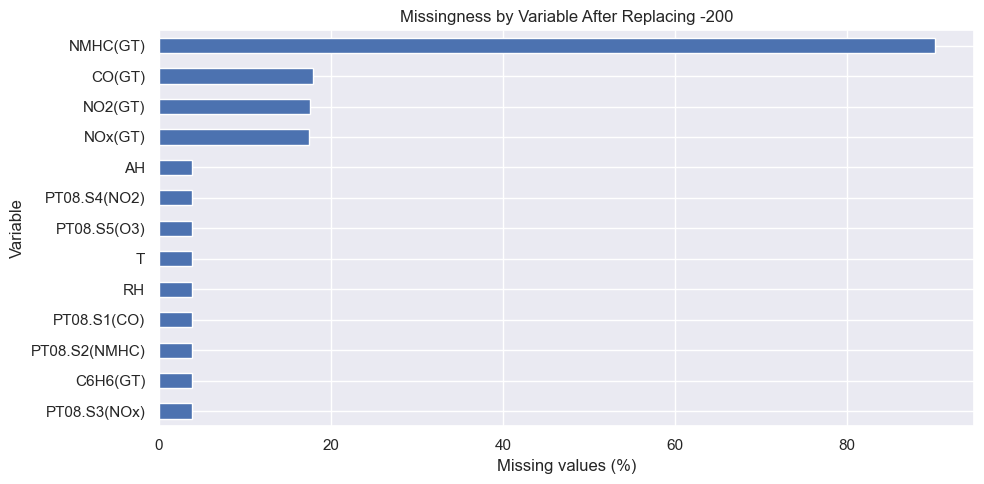

In [7]:
# EDA ACTION: visualize missingness so differences in scale are immediately visible.
plt.figure(figsize=(10, 5))

# SYNTAX: sort_values() puts the smallest bars first;
# kind="barh" creates a horizontal bar chart.
missing_summary["missing_percent"].sort_values().plot(kind="barh")

plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title("Missingness by Variable After Replacing -200")
plt.tight_layout()
plt.show()

## 7. Ask whether missingness has a time pattern

### EDA question

**Are missing observations scattered across the year or concentrated in particular periods?**

This changes missingness from a single percentage into a time-dependent phenomenon. Clusters may be consistent with outages, maintenance, or changes in the measurement process.

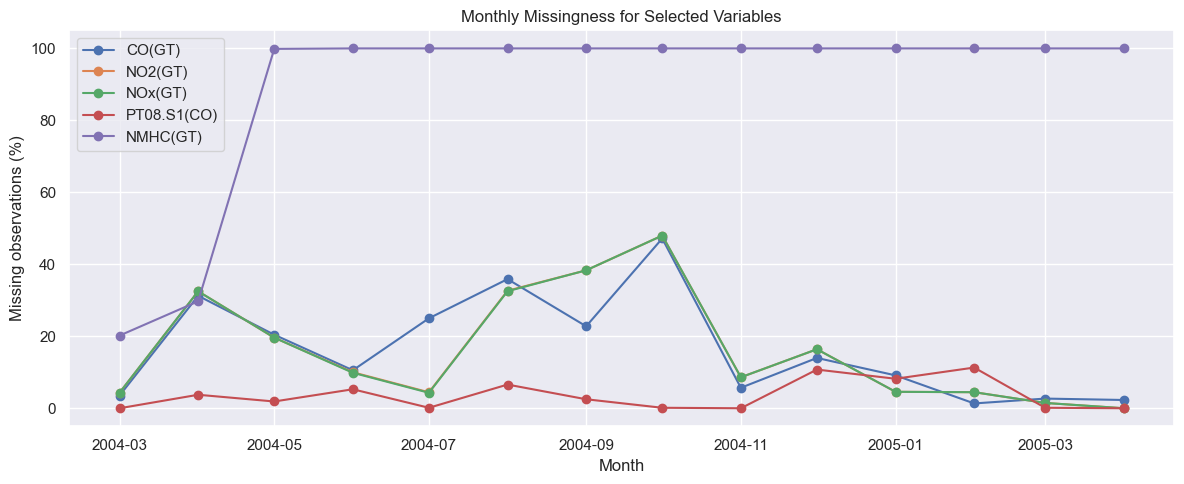

In [8]:
# EDA ACTION: calculate the percentage missing in each calendar month.
missing_over_time = (
    clean_df
    .set_index("Datetime")[numeric_cols]   # make time the dataframe index
    .isna()                               # True where a measurement is missing
    .resample("MS")                       # SYNTAX: group into month-start bins
    .mean()                               # fraction of True values in each month
    .mul(100)                             # convert fractions to percentages
)

selected_missing_cols = [
    col
    for col in ["CO(GT)", "NO2(GT)", "NOx(GT)", "PT08.S1(CO)", "NMHC(GT)"]
    if col in missing_over_time.columns
]

plt.figure(figsize=(12, 5))
for col in selected_missing_cols:
    plt.plot(
        missing_over_time.index,
        missing_over_time[col],
        marker="o",
        label=col,
    )

plt.ylabel("Missing observations (%)")
plt.xlabel("Month")
plt.title("Monthly Missingness for Selected Variables")
plt.legend()
plt.tight_layout()
plt.show()

### How this graph is interpreted

A flat line would indicate roughly similar missingness across periods. Peaks or blocks would show that missingness is **structured in time**.

This matters because interpolation across a short isolated gap is a different analytical assumption from interpolation across a prolonged period with no measurement.

## 8. Cleaning is an analytical assumption: compare imputation strategies

### EDA question

**How does each missing-value strategy change the data that will later be analysed?**

Three common strategies are compared for `CO(GT)`:

- mean imputation;
- forward filling;
- time interpolation.

The purpose is not to declare one method universally correct. The purpose is to make the consequences visible.

,Observed only,Mean,Forward fill,Time interpolation
mean,2.153,2.153,2.082,2.131
std,1.453,1.316,1.470,1.432
25%,1.100,1.200,1.000,1.100
50%,1.800,2.153,1.700,1.800
75%,2.900,2.600,2.800,2.900


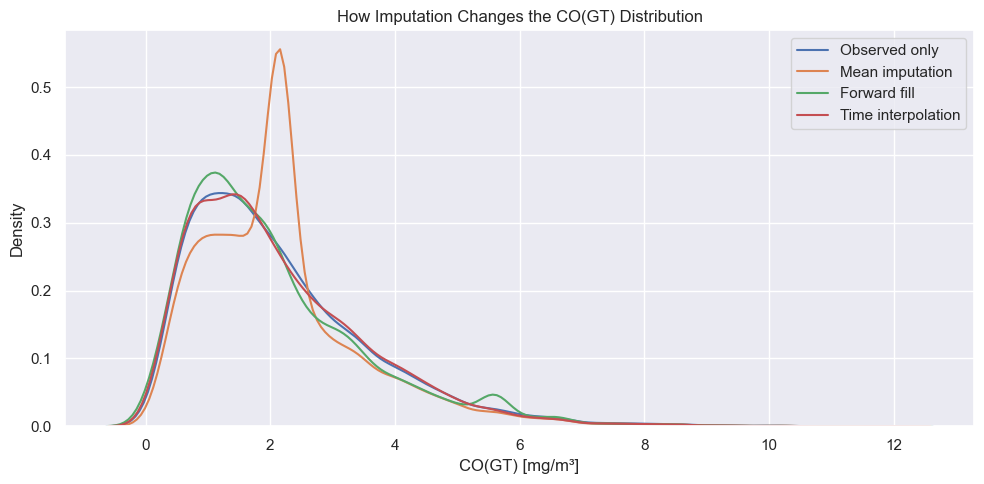

In [9]:
# EDA ACTION: create a time-indexed CO series while retaining genuine missing values.
co = clean_df.set_index("Datetime")["CO(GT)"].copy()

# Mean imputation replaces every missing value with one constant.
co_mean = co.fillna(co.mean())

# Forward fill copies the most recent observed value forward.
co_ffill = co.ffill()

# SYNTAX: method="time" uses the DatetimeIndex when estimating values
# between observed points.
co_linear = co.interpolate(method="time")

imputation_descriptives = pd.DataFrame({
    "Observed only": co.describe(),
    "Mean": co_mean.describe(),
    "Forward fill": co_ffill.describe(),
    "Time interpolation": co_linear.describe(),
})

display(
    imputation_descriptives
    .loc[["mean", "std", "25%", "50%", "75%"]]
    .round(3)
)

plt.figure(figsize=(10, 5))
sns.kdeplot(co.dropna(), label="Observed only")
sns.kdeplot(co_mean, label="Mean imputation")
sns.kdeplot(co_ffill.dropna(), label="Forward fill")
sns.kdeplot(co_linear.dropna(), label="Time interpolation")

plt.xlabel("CO(GT) [mg/m³]")
plt.title("How Imputation Changes the CO(GT) Distribution")
plt.legend()
plt.tight_layout()
plt.show()


### Finding

The density plot makes the distortion caused by mean imputation visually obvious. A sharp density spike appears around the imputed mean because many missing observations have been assigned exactly the same value.

The corresponding statistics are:

- mean imputation: mean ≈ **2.153**, standard deviation ≈ **1.316**;
- forward fill: mean ≈ **2.082**, standard deviation ≈ **1.470**;
- linear interpolation: mean ≈ **2.131**, standard deviation ≈ **1.432**.

The important learning is not that a particular method “wins.” It is that **cleaning changes the distribution**. Mean filling noticeably compresses variance because every imputed observation is placed at the centre.

An imputation decision is therefore part of the analysis, not housekeeping performed before the analysis begins.

### A small reconstruction test

Because the true values of genuinely missing observations are unknown, their imputation error cannot be measured directly. A simple educational diagnostic is to temporarily hide some values that *are* known, reconstruct them, and compare the reconstruction with the truth.

In [10]:
# SYNTAX: notna() creates a Boolean mask of observed CO values.
# to_numpy() converts it to a NumPy array.
# flatnonzero() returns the integer positions where the mask is True.
observed_positions = np.flatnonzero(co.notna().to_numpy())

# EDA ACTION: hide every twentieth observed point.
# The fixed rule makes the experiment reproducible.
holdout_positions = observed_positions[::20]

co_masked = co.copy()

# iloc selects by integer position rather than index label.
truth = co.iloc[holdout_positions].copy()
co_masked.iloc[holdout_positions] = np.nan

predictions = {
    "Mean": co_masked.fillna(co_masked.mean()).iloc[holdout_positions],
    "Forward fill": co_masked.ffill().iloc[holdout_positions],
    "Time interpolation": (
        co_masked.interpolate(method="time").iloc[holdout_positions]
    ),
}

scores = {}

for name, pred in predictions.items():
    # EDA ACTION: compare only positions where both prediction and truth exist.
    valid = pred.notna() & truth.notna()

    # SYNTAX: MAE is the average absolute distance between reconstruction and truth.
    mae = np.mean(np.abs(pred[valid] - truth[valid]))
    scores[name] = mae

display(
    pd.Series(scores, name="MAE")
    .sort_values()
    .to_frame()
    .round(3)
)

,MAE
Time interpolation,0.377
Forward fill,0.556
Mean,1.112


### What this experiment teaches

The experiment converts an intuition—“this imputation looks reasonable”—into a measurable diagnostic. It still does not prove how a method behaves inside every real missing interval, because deliberately hidden points may not have the same missingness mechanism as the original gaps.

EDA repeatedly uses this pattern:

> **Make an assumption visible, then look for evidence about its consequences.**

## 9. Univariate analysis: understand variables before relating them

### EDA question

**What does the distribution of an important measurement look like?**

Histograms, density curves, boxplots, medians, and quartiles answer different questions about centre, spread, skewness, and tails.

,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.152750,1.453252,0.1,1.1,1.8,2.9,11.9
NO2(GT),7715.0,113.091251,48.370108,2.0,78.0,109.0,142.0,340.0


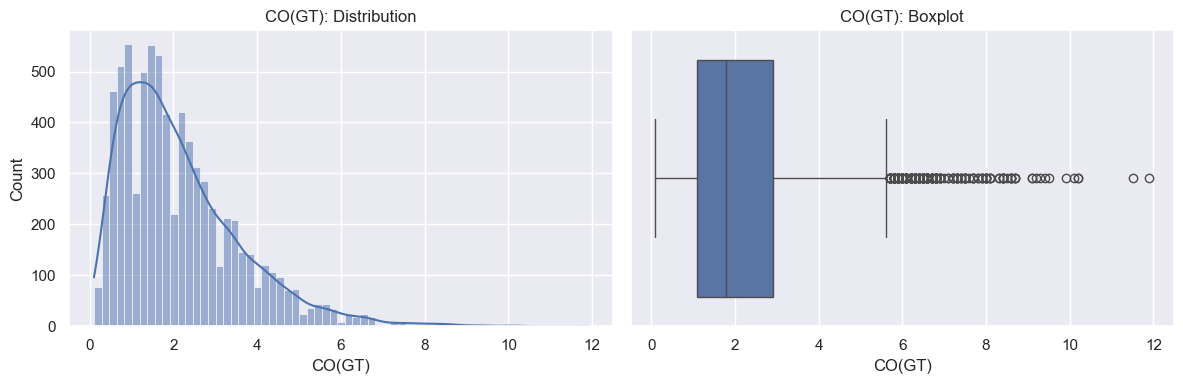

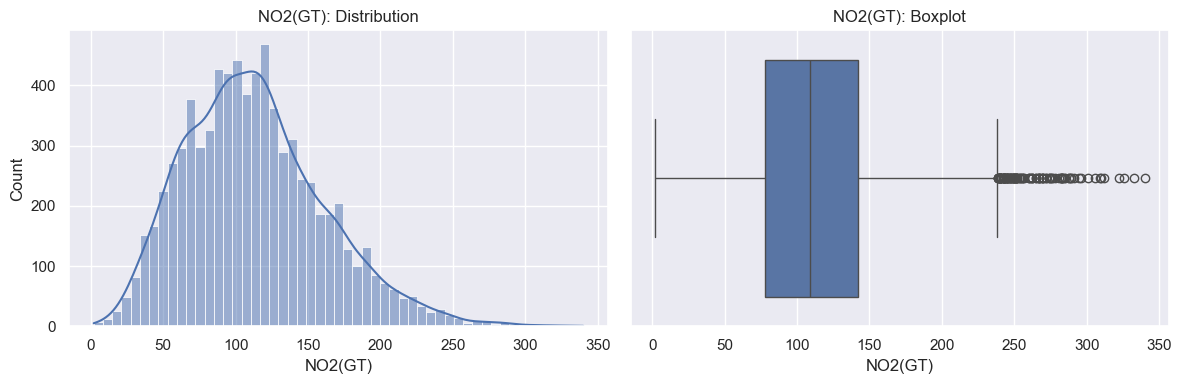

In [11]:
pollutants = ["CO(GT)", "NO2(GT)"]

# EDA ACTION: use observed values for descriptive EDA rather than forcing completeness.
display(clean_df[pollutants].describe().T)

for col in pollutants:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # dropna() removes missing observations only for this chart.
    sns.histplot(clean_df[col].dropna(), kde=True, ax=axes[0])
    sns.boxplot(x=clean_df[col].dropna(), ax=axes[1])

    axes[0].set_title(f"{col}: Distribution")
    axes[1].set_title(f"{col}: Boxplot")

    plt.tight_layout()
    plt.show()

### Findings from the pollutant distributions

After linear interpolation:

- `CO(GT)` has mean ≈ **2.13**, median **1.80**, and maximum **11.90**;
- `NO2(GT)` has mean ≈ **109.63**, median ≈ **104.92**, and maximum **340**.

For both variables, the mean lies above the median and the plots show a longer upper tail. This is evidence of **right-skewed distributions**: most observations occupy the lower-to-middle range, while a smaller number of much larger measurements extend the distribution.

That is why the median is useful alongside the mean. A single average would hide the shape of the tail.

### Temperature as an example of why one number can hide structure

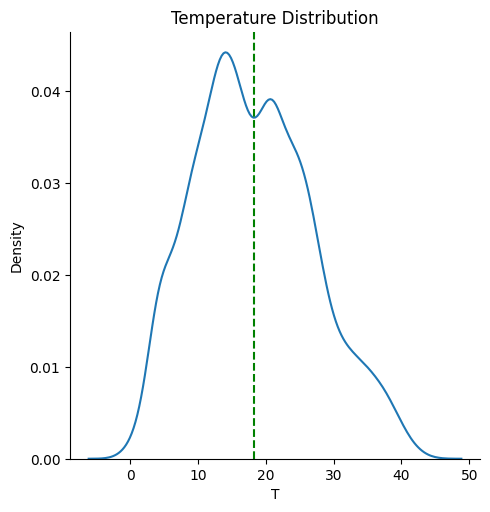

The temperature density is not a single perfectly symmetric bell. It contains visible shoulders and peaks across different temperature ranges, while the mean is about **18.2°C**.

Because the dataset spans many months, the distribution combines observations from different periods of the year. The plot therefore demonstrates a general EDA lesson:

> **A global average can mix together multiple regimes that become clearer when time is considered explicitly.**

## 10. Outlier diagnostics: identify unusual values without automatically deleting them

### EDA question

**Which observations lie far outside the central range of each variable?**

An IQR rule is useful as a flagging mechanism. It is not a truth detector. In environmental data, an extreme observation can be a genuine event, a sensor problem, or a data problem.

In [12]:
def iqr_outlier_summary(frame, columns):
    # REASONING: build one result row per variable.
    rows = []

    for col in columns:
        s = frame[col].dropna()

        # SYNTAX: quantile([.25, .75]) returns the first and third quartiles.
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        # | is element-wise OR: a value is flagged if it lies below
        # the lower fence OR above the upper fence.
        outlier_mask = (s < lower) | (s > upper)

        rows.append({
            "variable": col,
            "lower_fence": lower,
            "upper_fence": upper,
            "outlier_count": int(outlier_mask.sum()),
            "outlier_percent": 100 * outlier_mask.mean(),
        })

    return pd.DataFrame(rows).set_index("variable")

core_numeric = [col for col in numeric_cols if col != "NMHC(GT)"]

outlier_summary = iqr_outlier_summary(clean_df, core_numeric)

display(
    outlier_summary
    .sort_values("outlier_percent", ascending=False)
    .round(2)
)

,lower_fence,upper_fence,outlier_count,outlier_percent
variable,,,,
NOx(GT),-244.00,668.00,435,5.64
CO(GT),-1.60,5.60,215,2.80
PT08.S3(NOx),190.75,1436.75,241,2.68
C6H6(GT),-10.00,28.40,228,2.54
NO2(GT),-18.00,238.00,107,1.39
PT08.S1(CO),496.00,1672.00,118,1.31
PT08.S4(NO2),556.50,2344.50,97,1.08
PT08.S5(O3),-81.50,2086.50,93,1.03
PT08.S2(NMHC),162.25,1688.25,65,0.72


### Interpretation rule

The output identifies **unusual statistical positions**, not erroneous observations.

This is another recurring EDA distinction:

> **Detection is not deletion.**

An extreme value becomes a question that requires context. Removing it automatically would risk deleting exactly the kind of rare environmental episode the data may be intended to capture.

## 11. Correlation: quantify association, then inspect it

### EDA question

**Which variables move together, and does the answer depend on how association is measured?**

Two measures are useful here:

- **Pearson correlation** — strength of linear association;
- **Spearman correlation** — strength of monotonic rank association.

A correlation coefficient is evidence of association. It is not evidence of causation.

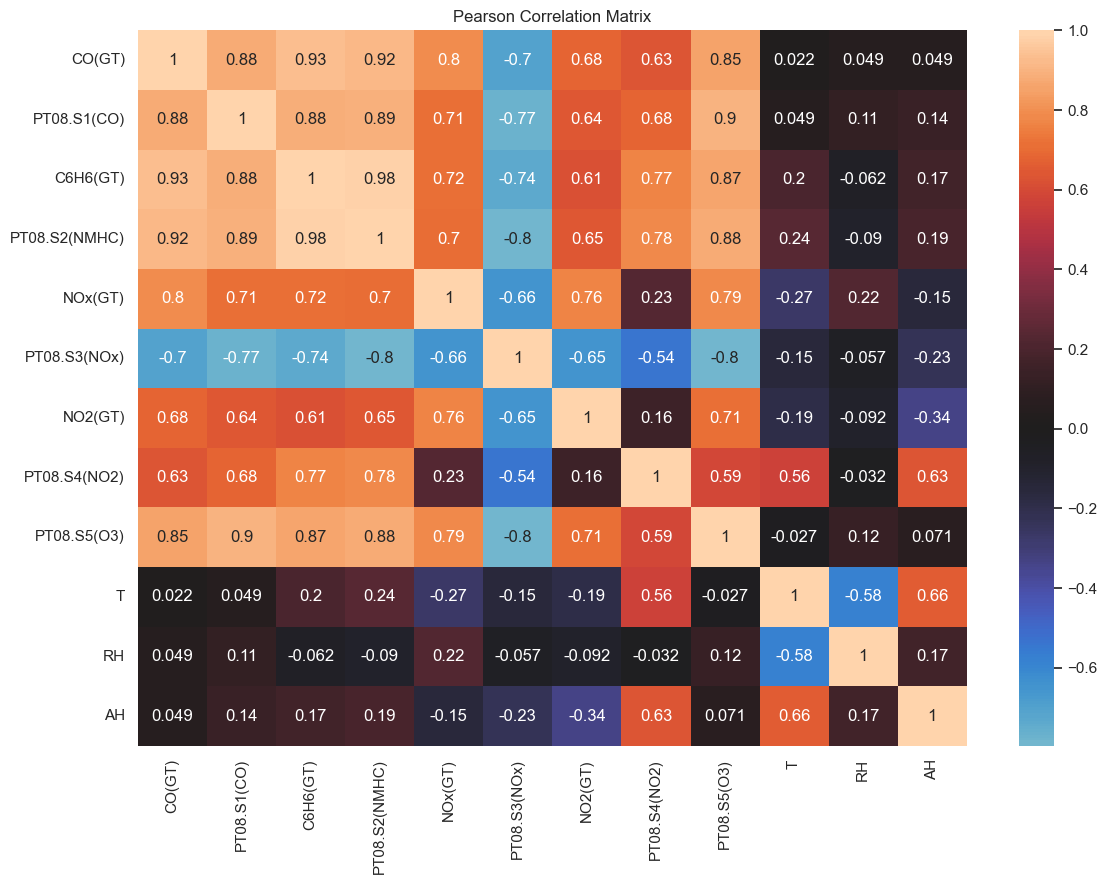

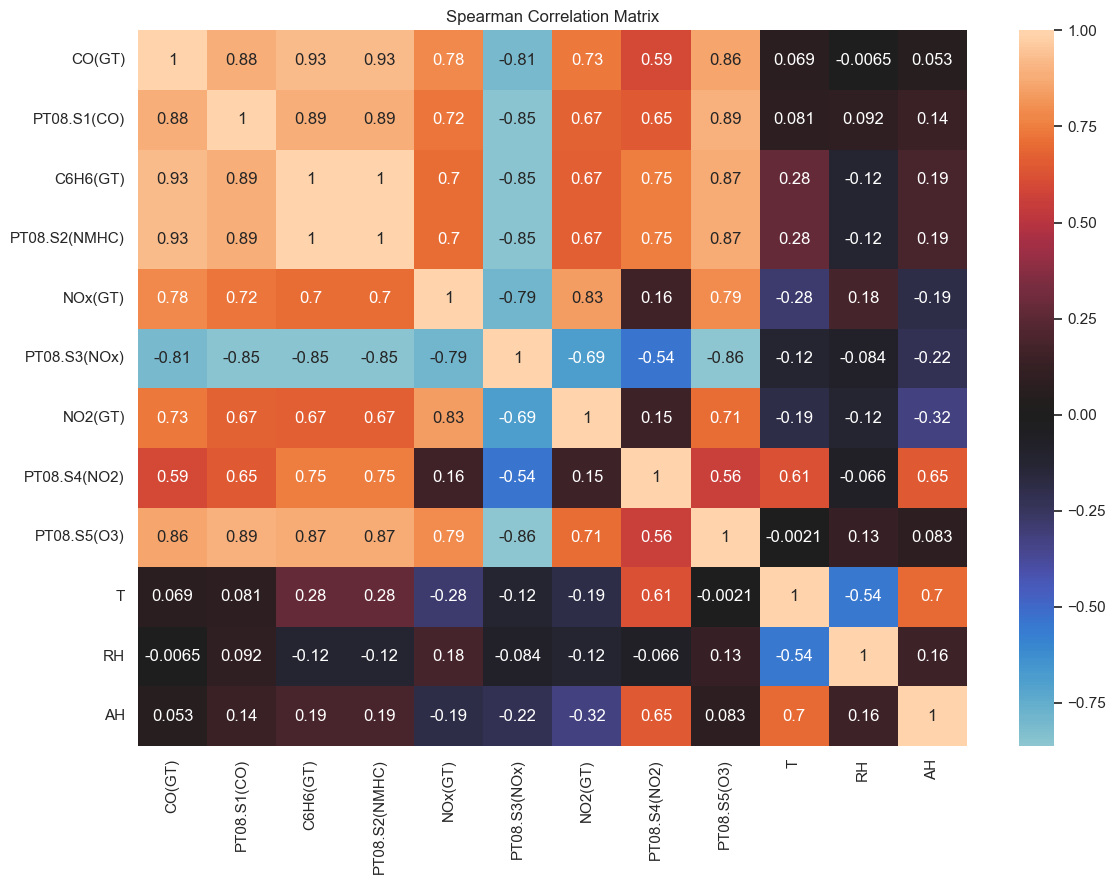

,Pearson,Spearman
NOx(GT),0.763,0.835
PT08.S5(O3),0.708,0.709
CO(GT),0.683,0.735
PT08.S3(NOx),-0.652,-0.689
PT08.S2(NMHC),0.646,0.669
PT08.S1(CO),0.642,0.673
C6H6(GT),0.614,0.669
AH,-0.335,-0.323
T,-0.187,-0.190
PT08.S4(NO2),0.157,0.154


In [22]:
# EDA ACTION: calculate two correlation matrices from the same observed variables.
pearson_corr = clean_df[core_numeric].corr(method="pearson")
spearman_corr = clean_df[core_numeric].corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(pearson_corr, center=0, annot=True)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(spearman_corr, center=0, annot=True)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

target = "NO2(GT)"

# SYNTAX: construct a two-column dataframe so the two measures can be compared.
target_corr = pd.DataFrame({
    "Pearson": pearson_corr[target],
    "Spearman": spearman_corr[target],
}).drop(index=target)

# abs() ranks relationships by strength regardless of positive/negative direction.
target_corr["abs_pearson"] = target_corr["Pearson"].abs()

display(
    target_corr
    .sort_values("abs_pearson", ascending=False)
    .drop(columns="abs_pearson")
    .round(3)
)

### A lesson from the high-NO₂ subset

The analysis also calculates Pearson correlations **after restricting the data to observations where `NO2(GT) > 200`**.

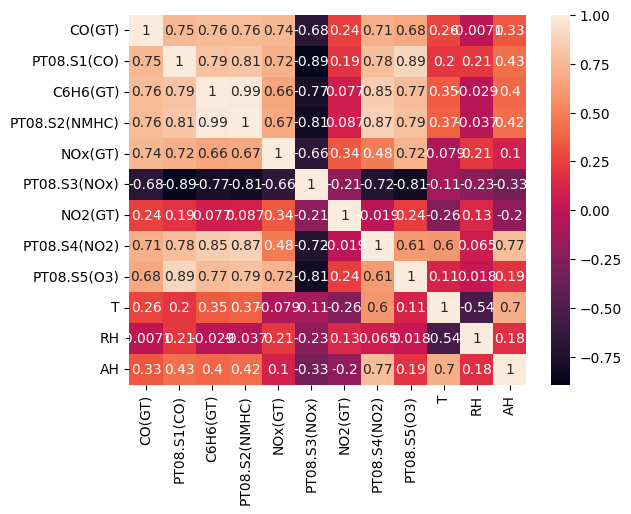

Within that restricted subset:

- `NOx(GT)` has the largest positive linear association with `NO2(GT)` at about **0.335**;
- `CO(GT)` is about **0.239**;
- `PT08.S5(O3)` is about **0.238**;
- temperature is about **−0.259**;
- `PT08.S3(NOx)` is about **−0.215**;
- `PT08.S4(NO2)` is approximately **−0.019**, indicating almost no linear association within this restricted range.

Squaring the largest non-self correlation gives roughly **0.11**. That value should be read narrowly: it is the squared bivariate Pearson association for `NOx(GT)` and `NO2(GT)` inside this restricted sample. It is **not** a model accuracy score.

This example teaches another important EDA principle: **subsetting changes the question**. Correlation inside only high-NO₂ observations describes variation *within the upper tail*, not the relationship across the complete dataset.

## 12. Scatterplots test whether a coefficient tells the whole story

### EDA question

**Does an apparently strong or weak correlation actually look like a stable relationship?**

Scatterplots reveal curvature, clusters, changing variance, and influential observations that a single number cannot show.

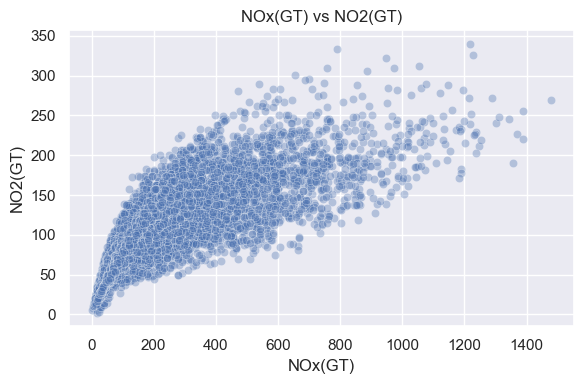

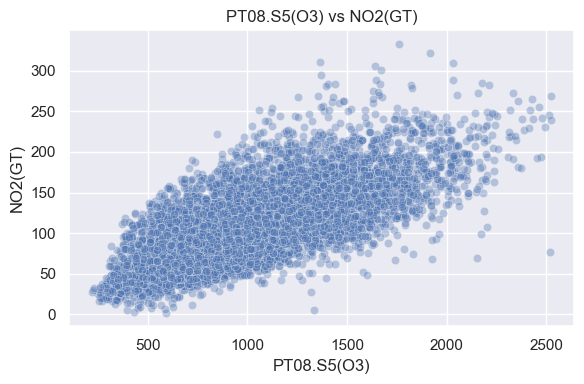

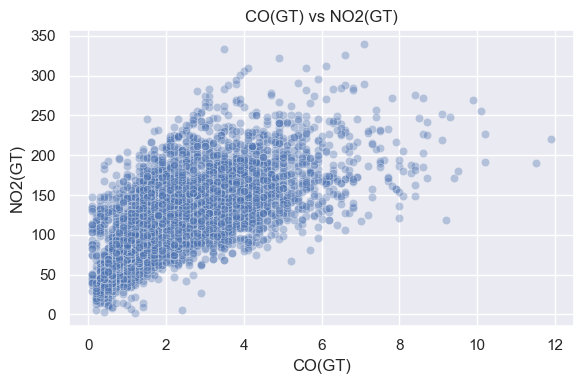

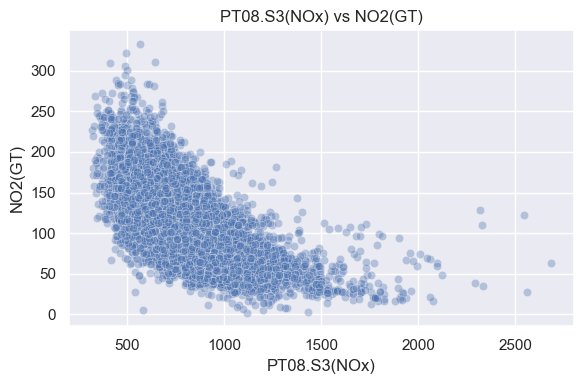

In [14]:
# Select the four largest absolute Pearson associations with NO2.
top_no2_features = (
    target_corr["Pearson"]
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

for feature in top_no2_features:
    # REASONING: use rows where both variables are actually observed.
    pair = clean_df[[feature, target]].dropna()

    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=pair,
        x=feature,
        y=target,
        alpha=0.35,   # SYNTAX: transparency makes dense regions easier to see
    )
    plt.title(f"{feature} vs {target}")
    plt.tight_layout()
    plt.show()

### Interpretation rule

A cloud of points can show a weak linear coefficient even when structure exists, and a strong coefficient can sometimes be driven by only part of the range.

The purpose of the scatterplot is therefore not decorative confirmation. It is a **diagnostic check on the correlation summary**.

## 13. Temporal EDA: the same variable can behave differently across time scales

The dataset is hourly, so time can be examined at several resolutions:

- across the full year;
- by day;
- by hour of day;
- by day of week;
- by month.

Each aggregation answers a different question. Temporal EDA is therefore not a single chart; it is a way of separating short-term cycles from broader movement.

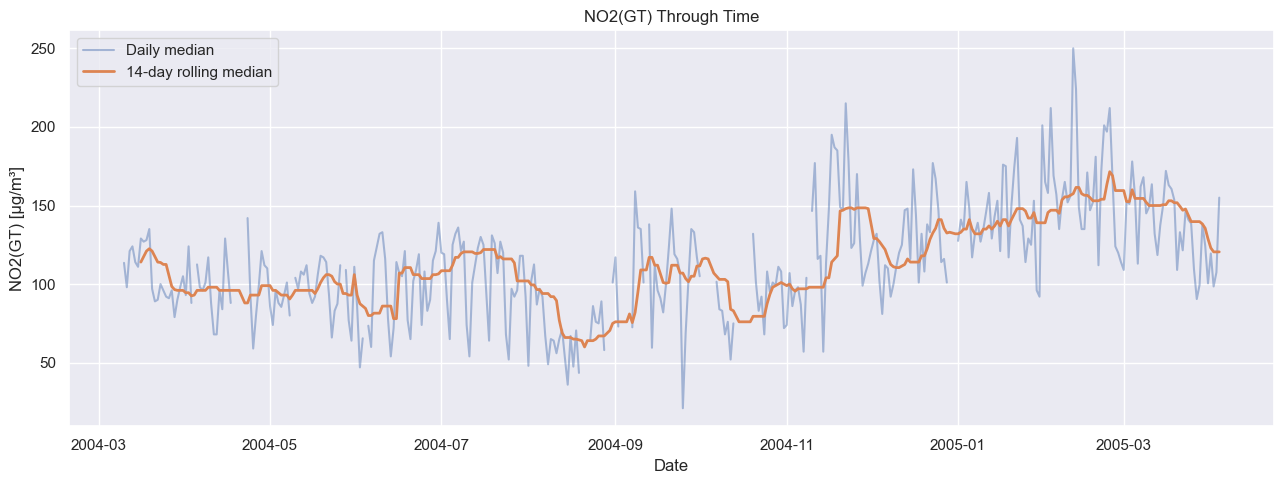

In [15]:
# Create a time-indexed dataframe for temporal operations.
ts_df = clean_df.set_index("Datetime").sort_index()

# EDA ACTION: reduce 24 hourly measurements into one daily median.
daily_no2 = ts_df["NO2(GT)"].resample("D").median()

# SYNTAX: rolling(14) uses a 14-observation window here because daily_no2
# contains one observation per day. min_periods=7 avoids plotting a statistic
# based on only one or two days at the beginning of the series.
rolling_no2 = daily_no2.rolling(14, min_periods=7).median()

plt.figure(figsize=(13, 5))
plt.plot(daily_no2.index, daily_no2, alpha=0.45, label="Daily median")
plt.plot(
    rolling_no2.index,
    rolling_no2,
    linewidth=2,
    label="14-day rolling median",
)

plt.ylabel("NO2(GT) [µg/m³]")
plt.xlabel("Date")
plt.title("NO2(GT) Through Time")
plt.legend()
plt.tight_layout()
plt.show()

### How to read the daily plot

The daily series retains abrupt episodes, while the rolling median suppresses short-term noise and emphasizes broader movement.

EDA deliberately uses both views because smoothing is a trade-off: it reveals slow structure while hiding some local extremes.

## 14. Weekly structure: compare weekdays and weekends

### EDA question

**Does NO₂ occupy the same distribution across the weekly activity cycle?**

,median,mean
Mon,105.0,110.30
Tue,115.0,117.39
Wed,117.0,120.01
Thu,116.0,120.84
Fri,119.0,123.45
Sat,101.0,107.57
Sun,85.0,91.66


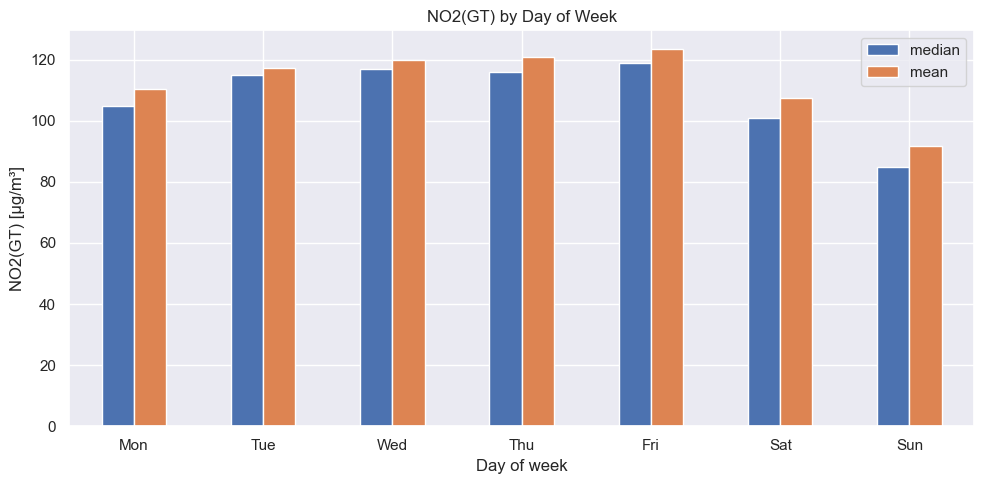

,count,mean,median,std
Day_Type,,,,
Weekday,5520,118.42,114.0,49.24
Weekend,2195,99.70,94.0,43.33


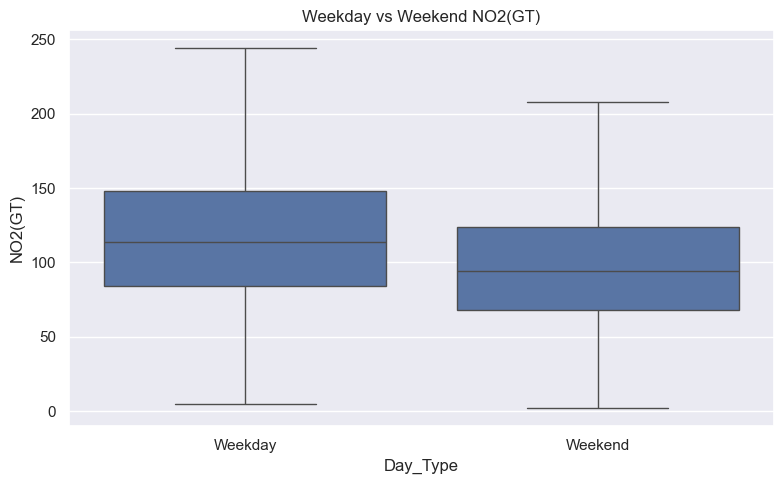

In [16]:
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# SYNTAX: index.dayofweek encodes Monday=0 through Sunday=6.
weekly_no2 = (
    ts_df
    .groupby(ts_df.index.dayofweek)["NO2(GT)"]
    .agg(["median", "mean"])
)

# Replace integer labels with readable day names.
weekly_no2.index = day_order
display(weekly_no2.round(2))

weekly_no2[["median", "mean"]].plot(kind="bar", figsize=(10, 5))
plt.xlabel("Day of week")
plt.ylabel("NO2(GT) [µg/m³]")
plt.title("NO2(GT) by Day of Week")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

weekday_weekend = ts_df[["NO2(GT)"]].copy()

# SYNTAX: np.where(condition, value_if_true, value_if_false)
# labels Saturday/Sunday as Weekend and all other days as Weekday.
weekday_weekend["Day_Type"] = np.where(
    weekday_weekend.index.dayofweek >= 5,
    "Weekend",
    "Weekday",
)

display(
    weekday_weekend
    .groupby("Day_Type")["NO2(GT)"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=weekday_weekend.reset_index(),
    x="Day_Type",
    y="NO2(GT)",
    order=["Weekday", "Weekend"],
    showfliers=False,
)
plt.title("Weekday vs Weekend NO2(GT)")
plt.tight_layout()
plt.show()

### Findings

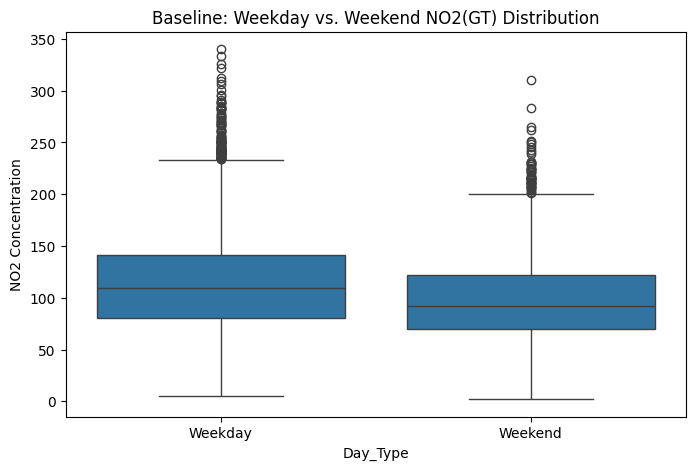

The grouped results show:

- weekday median NO₂: **109**;
- weekend median NO₂: **92**;
- weekday mean NO₂: about **114.0**;
- weekend mean NO₂: about **98.7**.

The day-of-week graph gives more detail:

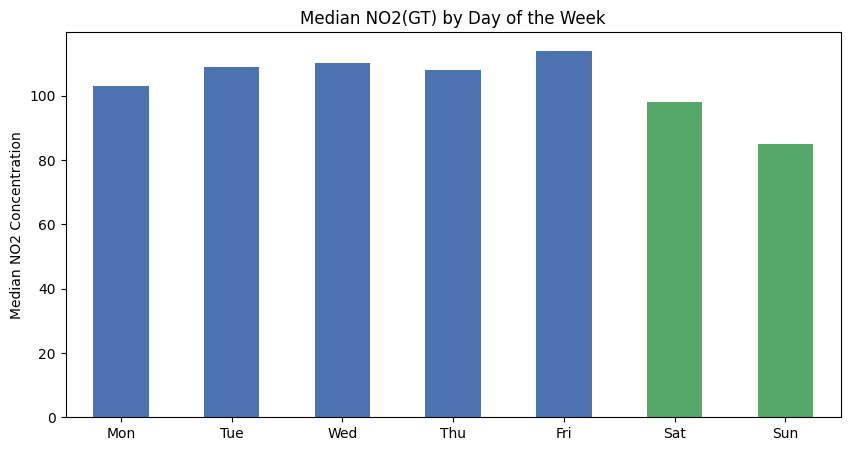

The weekday bars are generally higher than the weekend bars. Friday is the highest day in the displayed median profile, while Sunday is the lowest.

This supports a descriptive statement:

> **NO₂ measurements in this dataset tend to be higher on weekdays than on weekends.**

The graph does not by itself establish *why* the difference occurs. EDA separates the observed pattern from a causal explanation.

## 15. Hour-of-day profile: reveal the recurring daily cycle

### EDA question

**At what times of day are NO₂ measurements typically low or high?**

Comparing the mean and median is useful because a gap between them indicates that extreme observations are pulling the average away from the typical value.

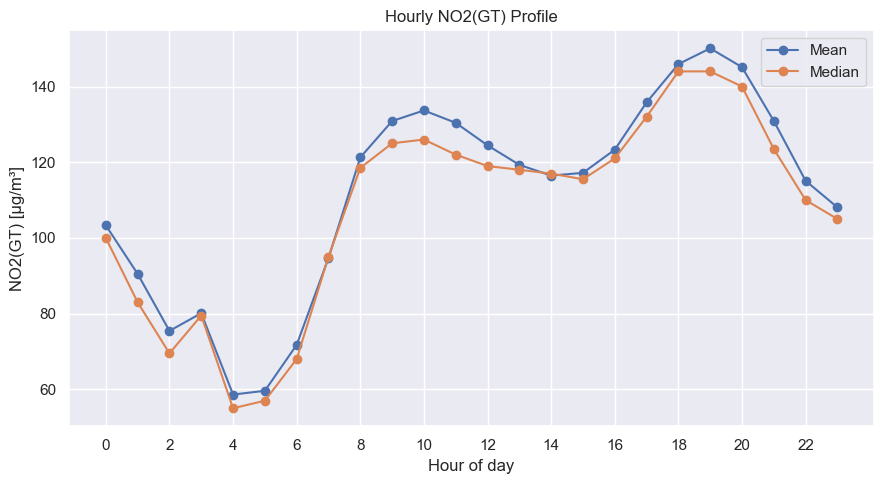

In [17]:
# SYNTAX: groupby(ts_df.index.hour) pools all observations taken at the same
# clock hour across all dates.
hourly_no2 = (
    ts_df
    .groupby(ts_df.index.hour)["NO2(GT)"]
    .agg(["mean", "median"])
)

plt.figure(figsize=(9, 5))
plt.plot(hourly_no2.index, hourly_no2["mean"], marker="o", label="Mean")
plt.plot(hourly_no2.index, hourly_no2["median"], marker="o", label="Median")

plt.xticks(range(0, 24, 2))
plt.xlabel("Hour of day")
plt.ylabel("NO2(GT) [µg/m³]")
plt.title("Hourly NO2(GT) Profile")
plt.legend()
plt.tight_layout()
plt.show()

### Finding

The hourly profile shows:

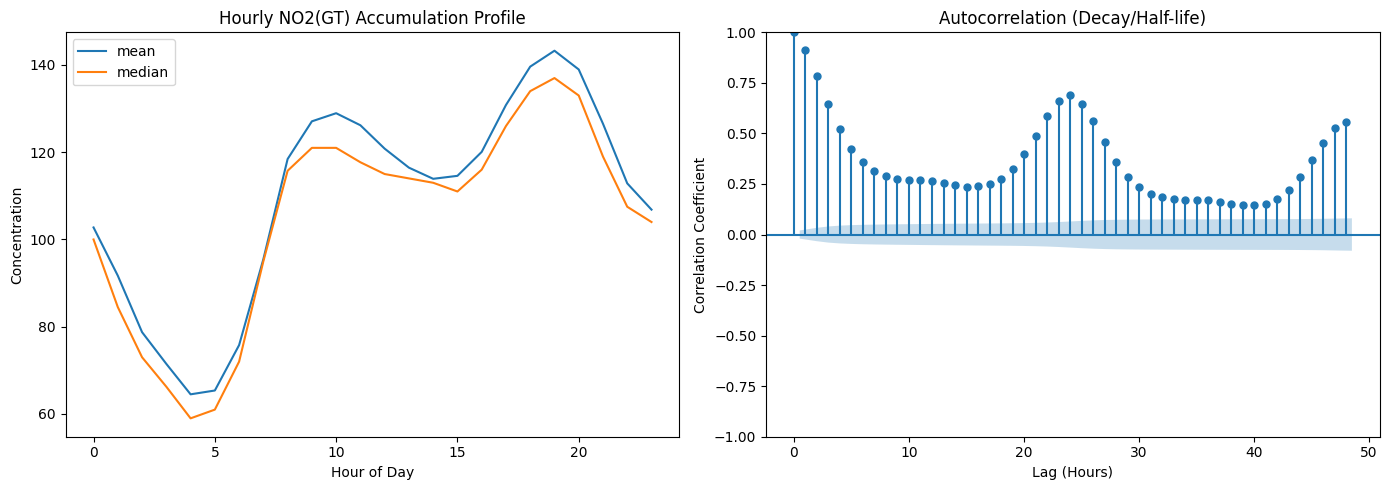

- a decline through the late night into an early-morning trough around **04:00–05:00**;
- a sharp morning increase;
- a morning high around the late-morning hours;
- a partial decline through the middle of the day;
- the largest displayed peak around **19:00**;
- a decline again later in the evening.

The mean generally sits above the median, especially around higher-concentration periods. That pattern is consistent with a right tail: unusually high observations pull the mean upward more strongly than the median.

The result demonstrates why temporal aggregation can expose structure that is invisible in the overall histogram.

## 16. Autocorrelation: measure how the recent past resembles the present

### EDA question

**Is an NO₂ measurement statistically related to measurements from previous hours?**

Autocorrelation compares a time series with lagged versions of itself. A lag of 1 compares each value with the previous hour; a lag of 24 compares each value with the same hour one day earlier.

Longest contiguous block used: 2246 hours


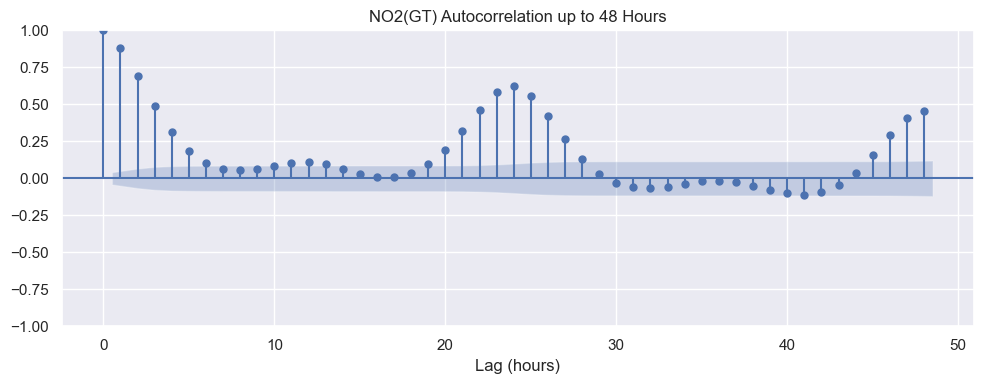

In [18]:
from statsmodels.graphics.tsaplots import plot_acf

# EDA ACTION: enforce a complete hourly index so "lag 24" truly means 24 hours.
hourly_index = pd.date_range(
    ts_df.index.min(),
    ts_df.index.max(),
    freq="h",
)

no2_hourly = ts_df["NO2(GT)"].reindex(hourly_index)

# REASONING: fill only short gaps for this diagnostic.
# limit=3 prevents interpolation from spanning arbitrarily long missing periods.
no2_short_interp = no2_hourly.interpolate(method="time", limit=3)

# SYNTAX:
# isna().cumsum() increases the group number each time a missing value is crossed.
# Grouping by that number separates contiguous non-missing blocks.
group_id = no2_short_interp.isna().cumsum()

blocks = [
    block.dropna()
    for _, block in no2_short_interp.groupby(group_id)
    if block.notna().any()
]

# Use the longest uninterrupted block so every lag has a consistent hourly meaning.
longest_block = max(blocks, key=len)

print("Longest contiguous block used:", len(longest_block), "hours")

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(longest_block, lags=48, ax=ax)

ax.set_xlabel("Lag (hours)")
ax.set_title("NO2(GT) Autocorrelation up to 48 Hours")
plt.tight_layout()
plt.show()

### Finding

The autocorrelation graph shows:

- very strong positive correlation at the first few hourly lags;
- a gradual decay through the following hours;
- a pronounced rise again around **24 hours**;
- another increase approaching **48 hours**.

The renewed peaks around daily intervals are evidence of a **repeating 24-hour structure**. The high short-lag values also show persistence: adjacent hours are not independent draws from the same distribution.

This changes how the dataset is understood. Time is part of the statistical structure, not simply metadata attached to each row.

## 17. Monthly profile: separate short cycles from broader seasonal movement

### EDA question

**Do pollutant and environmental measurements occupy different levels in different parts of the year?**

,CO(GT),NO2(GT),T,RH
Datetime,,,,
2004-03-01,2.10,101.0,14.05,52.20
2004-04-01,2.00,96.0,16.10,50.90
2004-05-01,1.80,96.0,19.20,43.80
2004-06-01,1.70,93.0,25.20,40.00
2004-07-01,1.60,104.0,28.10,33.10
2004-08-01,1.20,68.0,28.00,43.60
2004-09-01,1.85,107.0,23.70,43.80
2004-10-01,2.50,88.0,20.30,63.00
2004-11-01,2.30,118.0,13.25,60.60


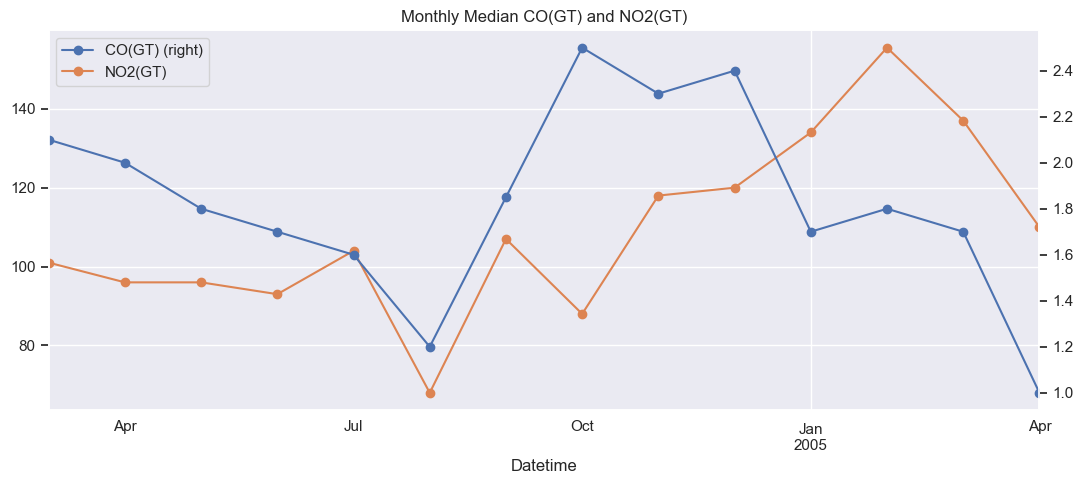

In [19]:
# SYNTAX: "MS" means month-start frequency.
# Each row below summarizes all observations in one calendar month.
monthly_profile = (
    ts_df
    .resample("MS")[["CO(GT)", "NO2(GT)", "T", "RH"]]
    .median()
)

display(monthly_profile.round(2))

# Two pollutants have different numerical scales, so a secondary y-axis
# keeps both readable in the same temporal view.
monthly_profile[["CO(GT)", "NO2(GT)"]].plot(
    figsize=(11, 5),
    marker="o",
    secondary_y="CO(GT)",
)

plt.title("Monthly Median CO(GT) and NO2(GT)")
plt.tight_layout()
plt.show()

### Interpretation rule

Monthly aggregation asks a different question from the hourly profile. The hourly graph looks for a recurring within-day cycle, whereas the monthly graph looks for broad shifts across the observation period.

EDA often works by **changing the scale of observation** until different forms of structure become visible.

## 18. High-concentration events: define “unusual” without inventing a health threshold

A dataset-relative event can be useful for exploration without claiming medical or regulatory significance.

Here an observed NO₂ value above the dataset's **95th percentile** is treated as a high-concentration event. This definition means “unusually high relative to this dataset,” and nothing more.

Dataset 95th-percentile NO2(GT) threshold: 200.30 µg/m³


,hours_above_threshold,max_no2,median_no2
Date,,,
2005-02-12,19,265.0,225.0
2005-02-11,15,340.0,276.0
2005-02-03,13,333.0,235.0
2005-02-22,13,295.0,218.0
2005-02-24,12,270.0,262.0
2004-11-22,12,245.0,236.0
2005-01-31,11,285.0,256.0
2004-11-18,10,282.0,222.5
2005-02-23,10,249.0,229.0


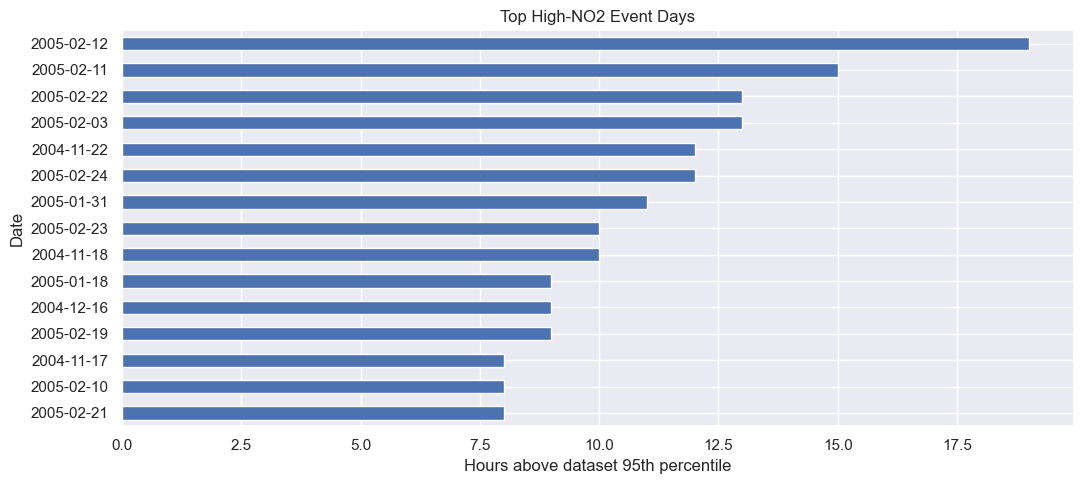

In [20]:
no2 = ts_df["NO2(GT)"]

# SYNTAX: quantile(0.95) returns the value below which 95% of observed values fall.
high_no2_threshold = no2.quantile(0.95)

print(
    f"Dataset 95th-percentile NO2(GT) threshold: "
    f"{high_no2_threshold:.2f} µg/m³"
)

# EDA ACTION: keep only observations above the exploratory threshold.
high_no2 = ts_df.loc[
    no2 > high_no2_threshold,
    ["NO2(GT)"],
].copy()

high_no2["Date"] = high_no2.index.date

# Named aggregation creates readable output column names.
top_event_days = (
    high_no2
    .groupby("Date")["NO2(GT)"]
    .agg(
        hours_above_threshold="size",
        max_no2="max",
        median_no2="median",
    )
    .sort_values(
        ["hours_above_threshold", "max_no2"],
        ascending=False,
    )
    .head(15)
)

display(top_event_days.round(2))

plt.figure(figsize=(11, 5))
top_event_days["hours_above_threshold"].sort_values().plot(kind="barh")

plt.xlabel("Hours above dataset 95th percentile")
plt.ylabel("Date")
plt.title("Top High-NO2 Event Days")
plt.tight_layout()
plt.show()

### What this section demonstrates

High NO₂ values cluster on some of the same dates; using a dataset-relative percentile preserves this useful pattern while keeping the interpretation descriptive.

EDA can therefore identify:

- isolated extreme measurements;
- sustained multi-hour episodes;
- dates on which upper-tail observations cluster.

The percentile is a **statistical reference point**, not a health or legal standard.

## 19. Relationship stability: a single annual correlation may hide change

### EDA question

**Does the sensor/reference relationship remain similar throughout the observation period?**

A correlation calculated over the full dataset compresses all dates into one number. Rolling correlation asks whether that relationship changes through time.

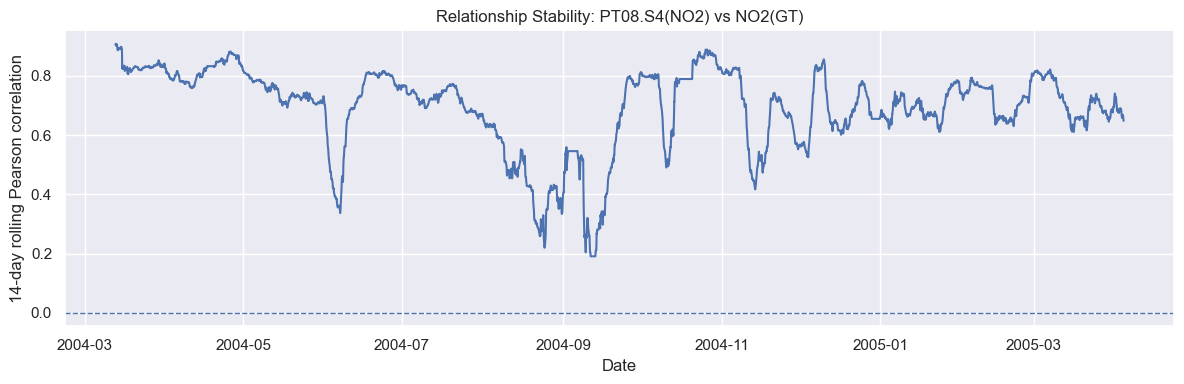

In [21]:
sensor_col = "PT08.S4(NO2)"
reference_col = "NO2(GT)"

# SYNTAX:
# rolling("14D") uses a time-based 14-day window.
# min_periods=48 requires at least 48 paired observations before a value is shown.
# corr(other_series) computes the Pearson correlation inside each moving window.
rolling_corr = (
    ts_df[sensor_col]
    .rolling("14D", min_periods=48)
    .corr(ts_df[reference_col])
)

plt.figure(figsize=(12, 4))
plt.plot(rolling_corr.index, rolling_corr)

# A horizontal zero line makes changes in direction easy to see.
plt.axhline(0, linestyle="--", linewidth=1)

plt.ylabel("14-day rolling Pearson correlation")
plt.xlabel("Date")
plt.title(f"Relationship Stability: {sensor_col} vs {reference_col}")
plt.tight_layout()
plt.show()

### How this graph is interpreted

A nearly flat rolling-correlation line would support the idea of a relatively stable relationship. Large movements would show that the association is time-dependent.

The purpose of this EDA step is not to prove a mechanism. It is to test whether a single global coefficient is an adequate summary of the full observation period.

## 20. Synthesis: what the exploration has established

EDA is complete here because the notebook has converted an initially opaque table into a structured set of evidence.

### Data quality

- `-200` is an encoded missing value, so raw non-null counts overstate completeness.
- Missingness differs substantially by variable.
- `NMHC(GT)` is an extreme case, with only 914 observed values in this dataset.
- Missingness must be understood before summary statistics or imputation are trusted.

### Cleaning behaviour

- Mean imputation visibly creates an artificial concentration of CO values at the mean.
- Different imputation rules alter variance and distributional shape.
- A cleaning rule is therefore an analytical assumption with measurable consequences.

### Distributional behaviour

- CO and NO₂ are right-skewed in this dataset.
- Means alone do not describe the upper tails.
- Extreme observations should be investigated rather than automatically removed.

### Relationships

- Correlation is a summary of association, not a causal conclusion.
- Pearson and Spearman answer different questions.
- Scatterplots are necessary to inspect whether a single coefficient is representative.
- The high-NO₂ subset illustrates that restricting the range changes the correlation question itself.

### Temporal behaviour

- Weekday NO₂ is higher than weekend NO₂ in this dataset.
- The day-of-week profile is lowest on Sunday and highest on Friday in the displayed medians.
- The hourly profile shows a clear within-day cycle, including an early-morning trough and a strong evening peak.
- Autocorrelation shows both short-term persistence and a repeating pattern around 24-hour intervals.

### Stability and scope

- Time-series structure means rows are not interchangeable independent observations.
- Rolling analysis is used to check whether relationships remain stable rather than assuming one annual coefficient describes every period.
- Dataset-relative extreme-event analysis can describe unusual episodes without converting an arbitrary exploratory cut-off into a health claim.

The central lesson is:

> **Exploratory Data Analysis is the disciplined process of learning what the data can support before asking it to support more.**

## 21. The EDA thinking process, compressed

The sequence used throughout this notebook can be reused as a mental model for understanding exploratory work:

```text
REAL-WORLD PROCESS
        ↓
DATASET
        ↓
What does one row mean?
        ↓
Can the structure be trusted?
        ↓
What is missing or invalid?
        ↓
How do cleaning choices alter the evidence?
        ↓
What does each important variable look like?
        ↓
How do variables relate?
        ↓
Does time or segmentation change the relationship?
        ↓
Are the findings stable?
        ↓
What is observed?
What is interpreted?
What remains uncertain?
```

EDA is therefore not defined by a particular plot, library, or statistical test.

It is defined by the **reasoning chain that connects the data-generating process to a defensible interpretation**.

## References

- Vito, S. (2008). **Air Quality** [Dataset]. UCI Machine Learning Repository. DOI: https://doi.org/10.24432/C59K5F
- UCI Air Quality dataset page: https://archive.ics.uci.edu/dataset/360/air+quality
- `ucimlrepo`: https://github.com/uci-ml-repo/ucimlrepo